<a href="https://colab.research.google.com/github/mkondzie/box-office/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Box Office Performance

This project analyzes movie revenue data, enriches it with movie details from the OMDb API, and presents a ranking dashboard based on various metrics. The notebook includes a data pipeline, including API data fetching with caching to manage API limits, data cleaning, creation of a star schema (fact and dimension tables), and visualization.

## Table of Contents
- [Setup and Installation](#setup-and-installation)
- [Data Files](#data-files)
- [OMDb API Key](#omdb-api-key)
- [Project Structure](#project-structure)
- [Data Pipeline Overview](#data-pipeline-overview)
- [Ranking Dashboard Metrics](#ranking-dashboard-metrics)
- [Usage](#usage)
- [Caching Mechanism](#caching-mechanism)

## Setup and Installation

1.  **Google Colab**: This notebook is designed to run in Google Colab.
2.  **Mount Google Drive**: The notebook expects the `revenues_per_day.csv` file to be located in a specific path within your Google Drive. Ensure you mount your Google Drive at `/content/drive` within the Colab environment. The code includes a cell for this:
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    ```
3.  **Install Libraries**: The project uses `pandas`, `numpy`, `requests`, `python-dotenv`, `matplotlib`, and `seaborn`. `pandas`, `numpy`, `requests`, `matplotlib`, and `seaborn` are typically pre-installed in Google Colab. `python-dotenv` is explicitly installed:
    ```bash
    !pip install python-dotenv
    ```

## Data Files

*   [**`revenues_per_day.csv`**](https://drive.google.com/file/d/1rD3kqm6Kr8UWiTtq1-feyfFkZwhvWXzS/view?usp=sharing): This is the primary input data file, containing daily movie revenue records.
    *   **Location**: It is expected to be found at `/content/drive/MyDrive/revenues_per_day.csv`. Please adjust the path in the notebook if your file is located elsewhere.

## OMDb API Key

To fetch movie details, an OMDb API key is required.

1.  **Obtain an API Key**:
    *   Visit the [OMDb API website](http://www.omdbapi.com/apikey.aspx).
    *   Register for a free API key.
2.  **Store the API Key in Google Colab Secrets**:
    *   In your Google Colab notebook, click on the key icon (Secrets) in the left sidebar.
    *   Add a new secret with the name `API_KEY` and paste your OMDb API key as its value.
    *   Ensure "Notebook access" is toggled ON for this secret.
    *   The notebook will then retrieve the API key using `userdata.get("API_KEY")`.
  
## Project Structure

The notebook follows a structured approach:

1.  **Data Loading**: Loads `revenues_per_day.csv` from Google Drive.
2.  **API Integration**: Fetches additional movie details from the OMDb API.
3.  **Caching**: Implements a caching mechanism to save fetched API data to a local JSON file (`/content/drive/MyDrive/movies_omdb.json`) to prevent repeated API calls and manage daily limits.
4.  **Data Modeling**: Transforms the raw data into a star schema, comprising:
    *   **`fact_df`**: The fact table, containing daily revenue and theater counts, linked to dimension tables by foreign keys.
    *   **`movie_df`**: The movie dimension table, storing detailed movie information.
    *   **`date_df`**: The date dimension table, containing date-related attributes.
5.  **Data Cleaning**: Handles missing values and corrects data types.
6.  **Ranking Dashboard**: Aggregates data and visualizes top-ranked movies based on various performance indicators.

## Data Pipeline Overview

The notebook executes a consolidated data pipeline to ensure reproducibility and clarity:

1.  Loads `revenues_per_day.csv` into `df`.
2.  Initializes `movie_df` from `movie_records` (a variable populated from an initial API call, demonstrating the caching approach).
3.  Saves `movie_df` to `/content/drive/MyDrive/movies_omdb.json` for persistent caching.
4.  Processes `df` to create `date_df` with unique dates and time attributes.
5.  Assigns `movie_id` to `movie_df`.
6.  Filters `df` to include only movies for which OMDb data was retrieved.
7.  Merges `df`, `movie_df`, and `date_df` to form `fact_df`.
8.  Cleans and converts data types in `fact_df`.
9.  Converts `imdb_rating` and `imdb_votes` in `movie_df` to numeric types.
10. Calculates aggregated metrics (`total_revenue`, `theaters`, `imdb_rating`, `imdb_votes`) for the ranking dashboard.

## Ranking Dashboard Metrics

The dashboard visualizes top 10 rankings based on:

*   **Total Revenue**: Sum of all daily revenues for a movie.
*   **Number of Theaters**: The number of theaters a movie was screened in.
*   **IMDb Rating**: Movie rating from IMDb.
*   **IMDb Votes**: Number of votes received on IMDb.


## Usage

To run this notebook:

1.  Upload `revenues_per_day.csv` to `/content/drive/MyDrive/`.
2.  Obtain an OMDb API key and store it in Colab secrets as `API_KEY`.
3.  Open the notebook in Google Colab.
4.  Execute all cells in order. The pipeline is designed to be run sequentially.

## Caching Mechanism

The notebook incorporates a caching mechanism to avoid repeatedly hitting the OMDb API. After the initial API calls (or when the `movie_records` variable is available from a previous run), the fetched movie data is saved to `/content/drive/MyDrive/movies_omdb.json`. In subsequent runs or if the API limit is reached, the notebook can load movie details directly from this JSON cache, ensuring continued functionality without re-fetching.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import requests
from google.colab import userdata
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
!pip install python-dotenv

In [68]:
API_KEY = userdata.get("API_KEY")

def get_movie_data(title, api_key):
    url = "http://www.omdbapi.com/"
    params = {"apikey": api_key, "t": title}
    r = requests.get(url, params=params)
    return r.json()


In [69]:
df = pd.read_csv("/content/drive/MyDrive/revenues_per_day.csv", parse_dates=['date'])
assert df["revenue"].notnull().all()
df

,id,date,title,revenue,theaters,distributor
0,8b19ad43-3a7e-b14b-49e9-1f7a0eb1568e,2004-09-20,Sky Captain and the World of Tomorrow,925482,3170.0,Paramount Pictures
1,481fc700-fcdd-1919-c53c-09fcd423a596,2004-09-20,Resident Evil: Apocalypse,643680,3284.0,Screen Gems
2,06719cc2-c05e-8c0b-56b6-b8b13e056509,2004-09-20,Mr 3000,425375,2736.0,Walt Disney Studios Motion Pictures
3,3be8e4a8-2716-00be-80be-eb342ba3cbe7,2004-09-20,Wimbledon,416970,2034.0,Universal Pictures
4,c5f26b59-6a64-ae8e-8f58-7cefb09eadfe,2004-09-20,Cellular,412000,2749.0,New Line Cinema
...,...,...,...,...,...,...
337813,4fe930ae-1b51-1b69-d6ba-f1b087db791c,2023-03-06,The Fabelmans,7555,591.0,Universal Pictures
337814,a4f1ad5e-11c0-5b07-9fe1-7adcade7da8c,2023-03-06,Selfiee,4800,308.0,-
337815,225197d3-d1e9-aca0-68b6-ba9fe61b2dc6,2023-03-06,The Banshees of Inisherin,3158,270.0,Searchlight Pictures
337816,1110f122-765c-43a9-bccf-c26311a863a5,2023-03-06,Violent Night,530,49.0,Universal Pictures


In [70]:
df["date"] = pd.to_datetime(df["date"])

date_df = pd.DataFrame({
    "date": df["date"].unique()
})

date_df["date_id"] = range(1, len(date_df)+1)
date_df["year"] = date_df["date"].dt.year
date_df["month"] = date_df["date"].dt.month
date_df["day"] = date_df["date"].dt.day
date_df["weekday"] = date_df["date"].dt.weekday

date_df

,date,date_id,year,month,day,weekday
0,2004-09-20,1,2004,9,20,0
1,2017-08-16,2,2017,8,16,2
2,2002-09-07,3,2002,9,7,5
3,2001-09-02,4,2001,9,2,6
4,2000-02-03,5,2000,2,3,3
...,...,...,...,...,...,...
8450,2023-03-02,8451,2023,3,2,3
8451,2023-03-03,8452,2023,3,3,4
8452,2023-03-04,8453,2023,3,4,5
8453,2023-03-05,8454,2023,3,5,6


In [71]:
movies = df['title'].unique()

movie_records = []

In [72]:
output_file_path = '/content/drive/MyDrive/movies_omdb.json'

movie_records = []
loaded_from_cache = False

try:
    # Check if the cache file exists and is not empty
    if os.path.exists(output_file_path) and os.path.getsize(output_file_path) > 0:
        with open(output_file_path, 'r') as f:
            movie_records = json.load(f)
        loaded_from_cache = True
        print("Movie data loaded from cache.")
    else:
        print("Cache file not found or is empty. Fetching data from OMDb API...")
except Exception as e:
    print(f"Error loading from cache: {e}. Fetching data from OMDb API...")
    movie_records = [] # Ensure movie_records is empty if cache loading failed

# If data was not loaded from cache, proceed with API calls
if not loaded_from_cache:
    newly_fetched_records = []
    for title in movies:

        data = get_movie_data(title, API_KEY)

        if data.get("Response") == "False":
            print(f"Skipping {title}: {data.get('Error')}")
            continue
        if data.get("Error") == "Request limit reached!":
            print("Daily API limit reached. Stopping API calls.")
            break

        newly_fetched_records.append({
            "imdbID": data.get("imdbID"),
            "title": data.get("Title"),
            "year": data.get("Year"),
            "release_date": data.get("Released"),
            "runtime": data.get("Runtime"),
            "genre": data.get("Genre"),
            "director": data.get("Director"),
            "imdb_rating": data.get("imdbRating"),
            "imdb_votes": data.get("imdbVotes")
        })

    # Add newly fetched records to movie_records (if any were already loaded from a partial cache, this would append)
    movie_records.extend(newly_fetched_records)

    # Save only if new data was fetched (to avoid overwriting a full cache with partial API results)
    if newly_fetched_records:
        with open(output_file_path, 'w') as f:
            json.dump(movie_records, f, indent=4)
        print("Movie data fetched from API and saved to cache.")

print(f"Total movie records available: {len(movie_records)}")

Movie data loaded from cache.
Total movie records available: 736


In [73]:
movie_df = pd.DataFrame(movie_records)
movie_df['movie_id'] = range(1, len(movie_df) + 1)
movie_df['imdb_votes'] = movie_df['imdb_votes'].str.replace(',', '').astype(int)
movie_df['imdb_rating'] = pd.to_numeric(movie_df['imdb_rating'], errors='coerce')
movie_df

,imdbID,title,year,release_date,runtime,genre,director,imdb_rating,imdb_votes,movie_id
0,tt0346156,Sky Captain and the World of Tomorrow,2004,17 Sep 2004,106 min,"Action, Adventure, Mystery",Kerry Conran,6.1,90083,1
1,tt0318627,Resident Evil: Apocalypse,2004,10 Sep 2004,94 min,"Action, Horror, Sci-Fi",Alexander Witt,6.1,219794,2
2,tt0339412,Mr. 3000,2004,17 Sep 2004,104 min,"Comedy, Drama, Romance",Charles Stone III,5.6,15332,3
3,tt0360201,Wimbledon,2004,17 Sep 2004,98 min,"Comedy, Romance, Sport",Richard Loncraine,6.3,68364,4
4,tt0337921,Cellular,2004,10 Sep 2004,94 min,"Action, Crime, Thriller",David R. Ellis,6.5,109564,5
...,...,...,...,...,...,...,...,...,...,...
731,tt0414853,Barnyard,2006,04 Aug 2006,90 min,"Animation, Adventure, Comedy",Steve Oedekerk,5.6,37859,732
732,tt0383574,Pirates of the Caribbean: Dead Man's Chest,2006,07 Jul 2006,151 min,"Action, Adventure, Fantasy",Gore Verbinski,7.4,819899,733
733,tt0454919,Pulse,2006,11 Aug 2006,90 min,"Horror, Sci-Fi, Thriller",Jim Sonzero,4.7,31712,734
734,tt0435625,The Descent,2005,04 Aug 2006,99 min,"Adventure, Horror, Thriller",Neil Marshall,7.2,270097,735


In [74]:
movie_titles_for_filtering = movie_df['title'].unique()
print(f"Number of unique movie titles successfully retrieved from OMDB: {len(movie_titles_for_filtering)}")
filtered_df = df[df['title'].isin(movie_titles_for_filtering)]
print(f"Number of records in filtered_df: {len(filtered_df)}")
print(f"Number of unique movies in filtered_df: {filtered_df['title'].nunique()}")
filtered_df.head()

Number of unique movie titles successfully retrieved from OMDB: 736
Number of records in filtered_df: 67493
Number of unique movies in filtered_df: 728


,id,date,title,revenue,theaters,distributor
0,8b19ad43-3a7e-b14b-49e9-1f7a0eb1568e,2004-09-20,Sky Captain and the World of Tomorrow,925482,3170.0,Paramount Pictures
1,481fc700-fcdd-1919-c53c-09fcd423a596,2004-09-20,Resident Evil: Apocalypse,643680,3284.0,Screen Gems
3,3be8e4a8-2716-00be-80be-eb342ba3cbe7,2004-09-20,Wimbledon,416970,2034.0,Universal Pictures
4,c5f26b59-6a64-ae8e-8f58-7cefb09eadfe,2004-09-20,Cellular,412000,2749.0,New Line Cinema
5,f163b4aa-33dc-dd06-709b-29aeea06dd4c,2004-09-20,Hero,218000,1926.0,Miramax


In [75]:
fact_df = filtered_df.merge(
    movie_df[['title', 'movie_id']],
    on='title',
    how='left'

)

fact_df = fact_df.merge(
    date_df[["date_id", "date"]],
    on="date",
    how="left"
)

fact_df.drop(columns=["date"], inplace=True)
fact_df.drop(columns=["distributor"], inplace=True)
fact_df['theaters'] = fact_df['theaters'].fillna(0).astype(int)
fact_df['revenue'] = fact_df['revenue'].fillna(0).astype(int)

fact_df

,id,title,revenue,theaters,movie_id,date_id
0,8b19ad43-3a7e-b14b-49e9-1f7a0eb1568e,Sky Captain and the World of Tomorrow,925482,3170,1,1
1,481fc700-fcdd-1919-c53c-09fcd423a596,Resident Evil: Apocalypse,643680,3284,2,1
2,3be8e4a8-2716-00be-80be-eb342ba3cbe7,Wimbledon,416970,2034,4,1
3,c5f26b59-6a64-ae8e-8f58-7cefb09eadfe,Cellular,412000,2749,5,1
4,f163b4aa-33dc-dd06-709b-29aeea06dd4c,Hero,218000,1926,6,1
...,...,...,...,...,...,...
67488,cc5e0388-a363-f499-8592-eabbffb35167,Western,91,1,491,7622
67489,65553c9b-59de-dfe1-4c18-2838c0125708,Deep Sea,88758,46,315,7623
67490,49d36fe0-e8df-5127-244b-3bfa22f2066a,Syriana,19912,175,161,7623
67491,fc488f9d-2f04-fd92-2e9d-6e4b0de40f3b,Walk the Line,8633,148,145,7623


## Entity-Relationship (ER) Diagram Representation

### Overview of Data Model
This section illustrates the relationships between the `fact_df`, `movie_df`, and `date_df` DataFrames.

### Fact Table: `fact_df`
- **Columns**: `id`, `movie_id`, `date_id`, `revenue`, `theaters`
- **Primary Key**: `id`
- **Foreign Keys**:
    - `movie_id` references `movie_df.movie_id`
    - `date_id` references `date_df.date_id`

| Column Name | Data Type | Key Type |
|-------------|-----------|----------|
| `id`        | object    | PK       |
| `movie_id`  | int64     | FK       |
| `date_id`   | int64     | FK       |
| `revenue`   | int64     |          |
| `theaters`  | int64     |          |

### Dimension Table: `movie_df`
- **Columns**: `imdbID`, `title`, `year`, `release_date`, `runtime`, `genre`, `director`, `imdb_rating`, `imdb_votes`, `movie_id`
- **Primary Key**: `movie_id`

| Column Name    | Data Type | Key Type |
|----------------|-----------|----------|
| `movie_id`     | int64     | PK       |
| `imdbID`       | object    |          |
| `title`        | object    |          |
| `year`         | object    |          |
| `release_date` | object    |          |
| `runtime`      | object    |          |
| `genre`        | object    |          |
| `director`     | object    |          |
| `imdb_rating`  | float64   |          |
| `imdb_votes`   | int64     |          |

### Dimension Table: `date_df`
- **Columns**: `date`, `date_id`, `year`, `month`, `day`, `weekday`
- **Primary Key**: `date_id`

| Column Name | Data Type      | Key Type |
|-------------|----------------|----------|
| `date_id`   | int64          | PK       |
| `date`      | datetime64[ns] |          |
| `year`      | int32          |          |
| `month`     | int32          |          |
| `day`       | int32          |          |
| `weekday`   | int32          |          |


In [76]:
print('--- movie_df (Head and Info) ---')
display(movie_df.head())
movie_df.info()

print('\n--- date_df (Head and Info) ---')
display(date_df.head())
date_df.info()

print('\n--- fact_df (Head and Info) ---')
display(fact_df.head())
fact_df.info()


--- movie_df (Head and Info) ---


,imdbID,title,year,release_date,runtime,genre,director,imdb_rating,imdb_votes,movie_id
0,tt0346156,Sky Captain and the World of Tomorrow,2004,17 Sep 2004,106 min,"Action, Adventure, Mystery",Kerry Conran,6.1,90083,1
1,tt0318627,Resident Evil: Apocalypse,2004,10 Sep 2004,94 min,"Action, Horror, Sci-Fi",Alexander Witt,6.1,219794,2
2,tt0339412,Mr. 3000,2004,17 Sep 2004,104 min,"Comedy, Drama, Romance",Charles Stone III,5.6,15332,3
3,tt0360201,Wimbledon,2004,17 Sep 2004,98 min,"Comedy, Romance, Sport",Richard Loncraine,6.3,68364,4
4,tt0337921,Cellular,2004,10 Sep 2004,94 min,"Action, Crime, Thriller",David R. Ellis,6.5,109564,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   imdbID        736 non-null    object 
 1   title         736 non-null    object 
 2   year          736 non-null    object 
 3   release_date  736 non-null    object 
 4   runtime       736 non-null    object 
 5   genre         736 non-null    object 
 6   director      736 non-null    object 
 7   imdb_rating   736 non-null    float64
 8   imdb_votes    736 non-null    int64  
 9   movie_id      736 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 57.6+ KB

--- date_df (Head and Info) ---


,date,date_id,year,month,day,weekday
0,2004-09-20,1,2004,9,20,0
1,2017-08-16,2,2017,8,16,2
2,2002-09-07,3,2002,9,7,5
3,2001-09-02,4,2001,9,2,6
4,2000-02-03,5,2000,2,3,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8455 entries, 0 to 8454
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     8455 non-null   datetime64[ns]
 1   date_id  8455 non-null   int64         
 2   year     8455 non-null   int32         
 3   month    8455 non-null   int32         
 4   day      8455 non-null   int32         
 5   weekday  8455 non-null   int32         
dtypes: datetime64[ns](1), int32(4), int64(1)
memory usage: 264.3 KB

--- fact_df (Head and Info) ---


,id,title,revenue,theaters,movie_id,date_id
0,8b19ad43-3a7e-b14b-49e9-1f7a0eb1568e,Sky Captain and the World of Tomorrow,925482,3170,1,1
1,481fc700-fcdd-1919-c53c-09fcd423a596,Resident Evil: Apocalypse,643680,3284,2,1
2,3be8e4a8-2716-00be-80be-eb342ba3cbe7,Wimbledon,416970,2034,4,1
3,c5f26b59-6a64-ae8e-8f58-7cefb09eadfe,Cellular,412000,2749,5,1
4,f163b4aa-33dc-dd06-709b-29aeea06dd4c,Hero,218000,1926,6,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67493 entries, 0 to 67492
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        67493 non-null  object
 1   title     67493 non-null  object
 2   revenue   67493 non-null  int64 
 3   theaters  67493 non-null  int64 
 4   movie_id  67493 non-null  int64 
 5   date_id   67493 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 3.1+ MB


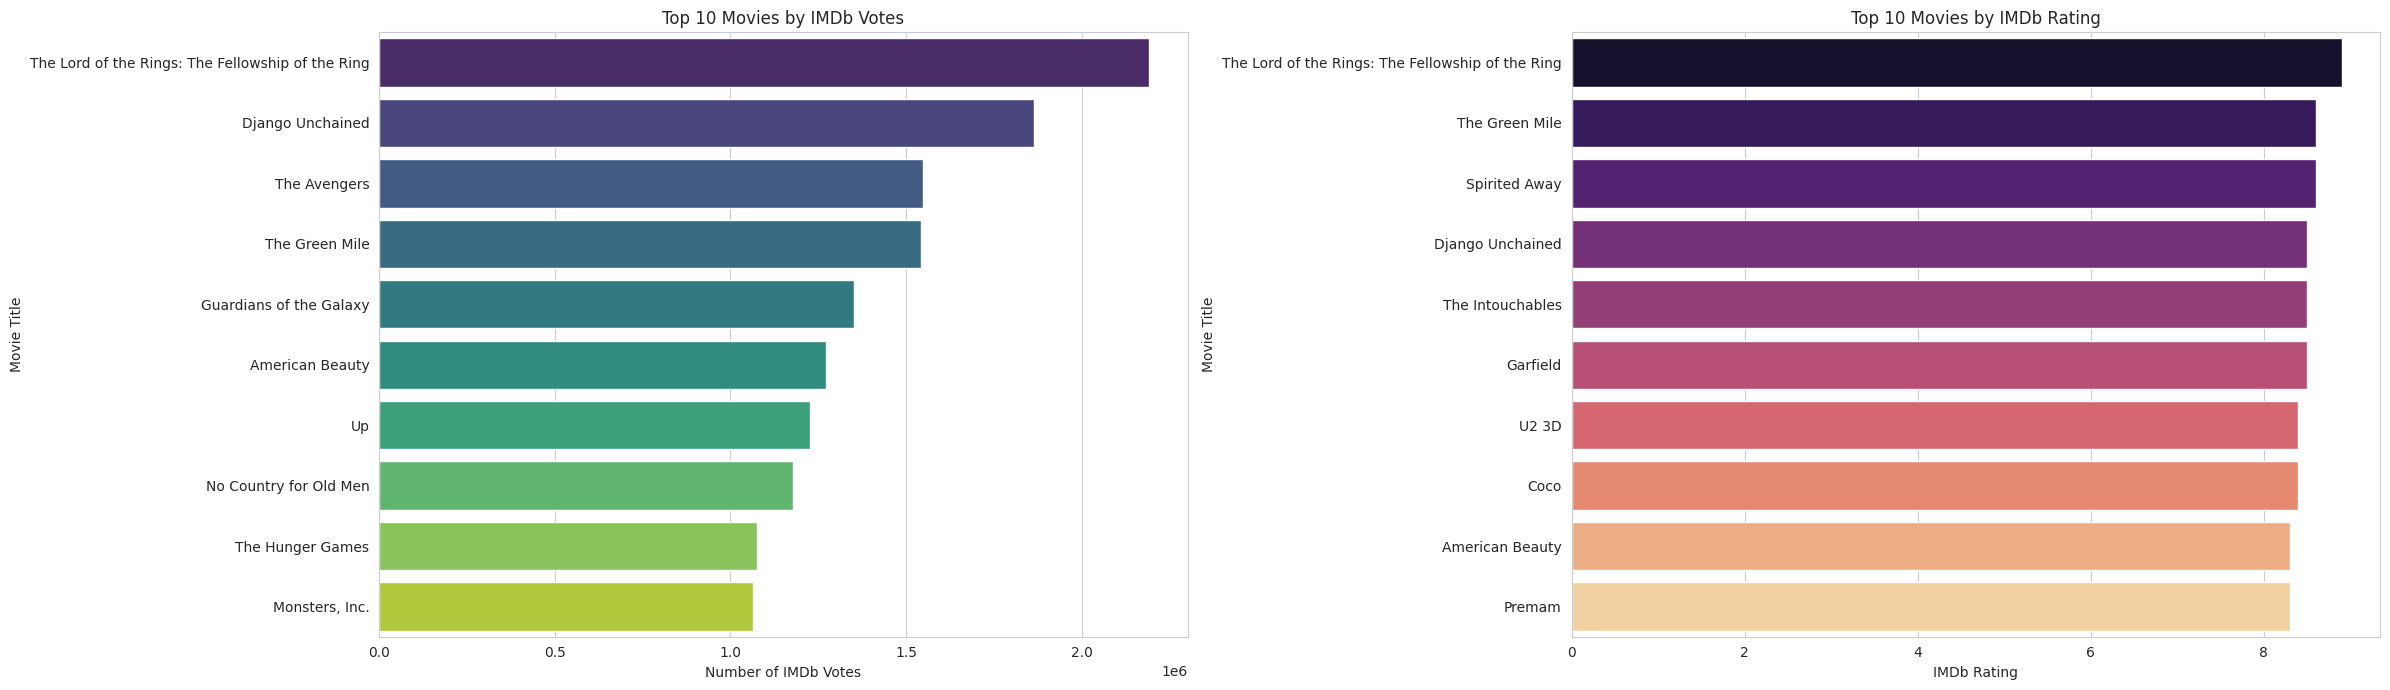

In [77]:
sns.set_style("whitegrid")

top_10_imdb_votes = movie_df.sort_values(by='imdb_votes', ascending=False).head(10)
top_10_imdb_rating = movie_df.sort_values(by='imdb_rating', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(24, 7)) # Create a figure with 2 subplots

# Plot Top 10 Movies by IMDb Votes
sns.barplot(x='imdb_votes', y='title', data=top_10_imdb_votes, palette='viridis', hue='title', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Movies by IMDb Votes')
axes[0].set_xlabel('Number of IMDb Votes')
axes[0].set_ylabel('Movie Title')

# Plot Top 10 Movies by IMDb Rating
sns.barplot(x='imdb_rating', y='title', data=top_10_imdb_rating, palette='magma', hue='title', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Movies by IMDb Rating')
axes[1].set_xlabel('IMDb Rating')
axes[1].set_ylabel('Movie Title')

plt.tight_layout()
plt.show()

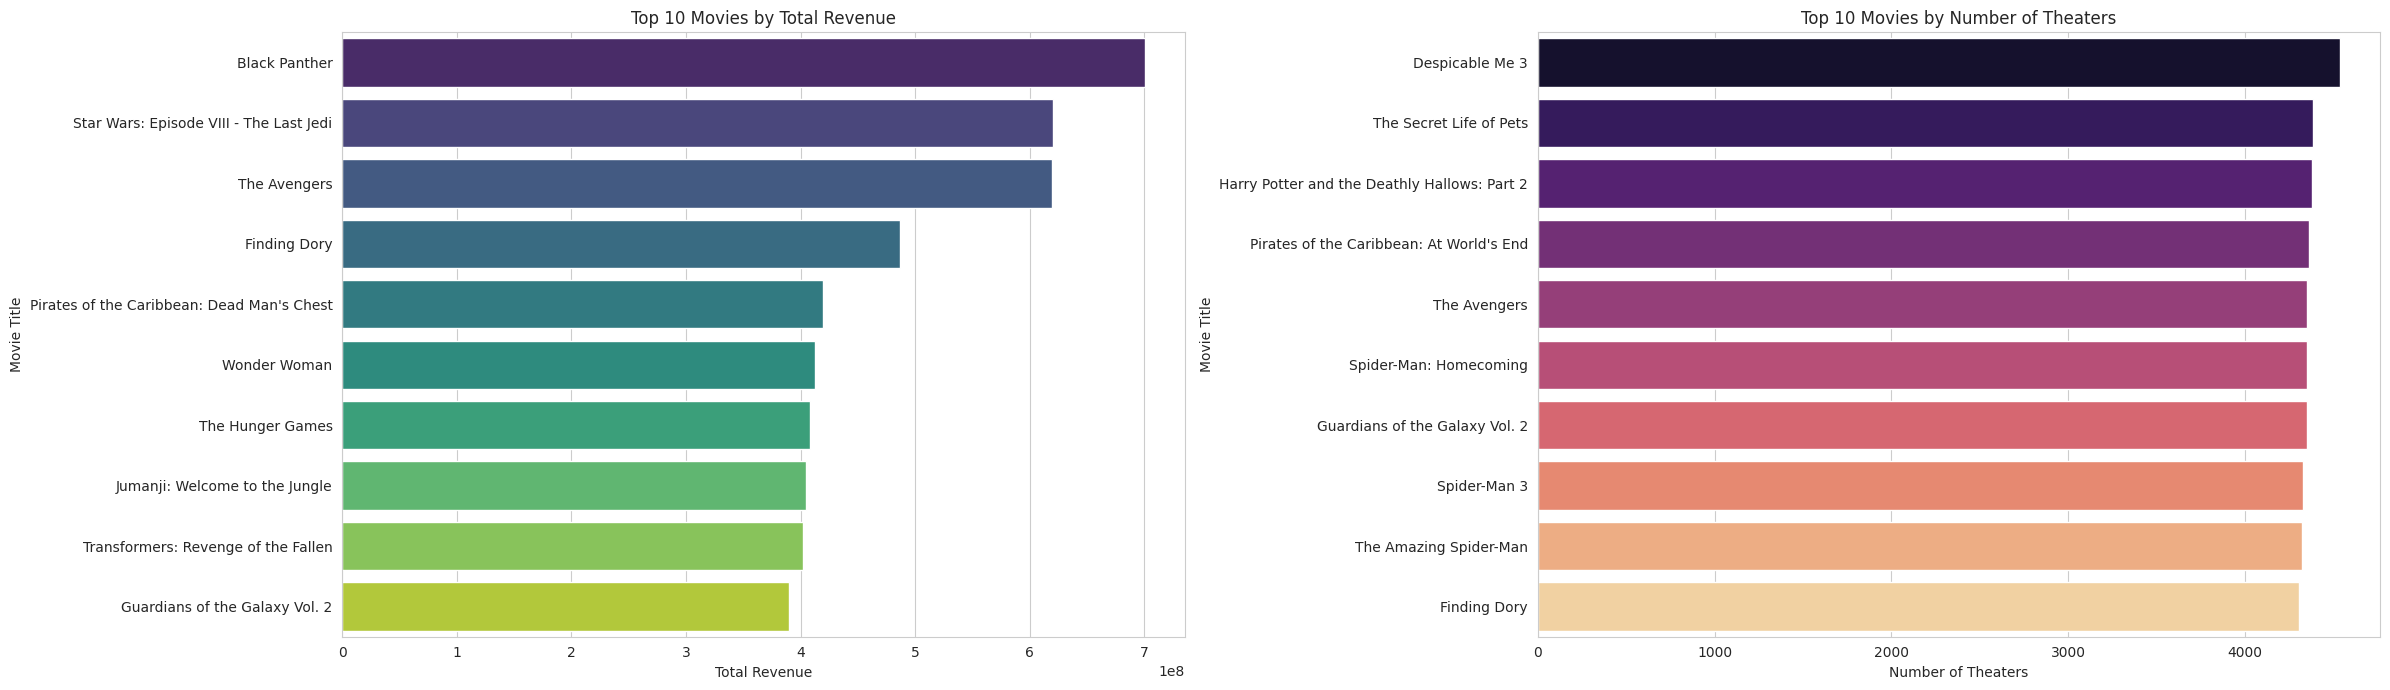

In [78]:
total_revenue_per_movie = fact_df.groupby('title')['revenue'].sum().reset_index()
top_10_revenue = total_revenue_per_movie.sort_values(by='revenue', ascending=False).head(10)

max_theaters_per_movie = fact_df.groupby('title')['theaters'].max().reset_index()
top_10_theaters = max_theaters_per_movie.sort_values(by='theaters', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(24, 7))

sns.barplot(x='revenue', y='title', data=top_10_revenue, palette='viridis', hue='title', legend=False, ax=axes[0])
axes[0].set_title('Top 10 Movies by Total Revenue')
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Movie Title')

sns.barplot(x='theaters', y='title', data=top_10_theaters, palette='magma', hue='title', legend=False, ax=axes[1])
axes[1].set_title('Top 10 Movies by Number of Theaters')
axes[1].set_xlabel('Number of Theaters')
axes[1].set_ylabel('Movie Title')

plt.tight_layout()
plt.show()